In [10]:
import pathlib
import random
import copy
import numpy as np
import torch

from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

from sliced_wasserstein import sliced_wasserstein_distance
from c2st import c2st_knn, c2st_nn, c2st_rf

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet
import seaborn as sns
import itertools

In [11]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""

def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

In [12]:
# adujst correctly for repetition
import pickle


def load_predicted_amplitude_for_subject(subject_index=2, rep=1):
    data_dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/gradshap_explanations_rep_{rep}"
    file_path = os.path.join(data_dir, f"gradshap_data_subject_{subject_index}_rep_{rep}.npy")

    #with open(file_path, 'rb') as f:
    #    subject_data = pickle.load(f)   
    #predictions, uncertainties, _ = subject_data['predictions'], subject_data['uncertainties'], subject_data['explanations']
    data = np.load(file_path, allow_pickle=True).item()
    predictions = data['predictions']
    cfg = load_config()
    cfg.dataset.subject_index = subject_index
    _, _, _, _, _, _, _, ch_names = load_eeg_data(cfg)
    
    return predictions,  ch_names

In [22]:
def load_distances_both(subject_index, pert_pairs, freq_bands, rep=1):
    dir = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation_distance_power_and_phase"
    
    distances = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        distances[band_name] = {}

        for factor, phase_shift in pert_pairs:
            file_path = f"parallel_distance_dict_{band_name}_channel_amp_factor_{factor}_phase_shift_{phase_shift}_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir, file_path)
            distances[band_name][(factor, phase_shift)] = np.load(load_path, allow_pickle=True).item()

    return distances

In [14]:
def load_distances_power(subject_index, factors, rep=1):
    dir = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation_distance_power"
    
    distances = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        distances[band_name] = {}

        for factor in factors:
            file_path = f"parallel_distance_dict_{band_name}_channel_amp_factor_{factor}_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir, file_path)
            distances[band_name][factor] = np.load(load_path, allow_pickle=True).item()

    return distances

In [30]:
def load_distances_phase(subject_index, factors, rep=1):
    dir = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase/parallel_perturbation_distance_phase"
    
    distances = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        distances[band_name] = {}

        for factor in factors:
            file_path = f"parallel_distance_dict_{band_name}_channel_phase_shift_{int(factor)}°_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir, file_path)
            distances[band_name][factor] = np.load(load_path, allow_pickle=True).item()

    return distances

In [43]:

def calculate_diff_per_channel_dw_power(pred_label_original, freq_bands, amplification_factors, ch_names, distances, subject_index=2, rep=1, dw=True):
    dir_constrained = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation_power"
    mean_diff_per_channel = {}
    median_diff_per_channel = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        mean_diff_per_channel[band_name] = {}
        median_diff_per_channel[band_name] = {}
        for factor in amplification_factors:
            file_path = f"parallel_perturbed_prediction_dict_{band_name}_channel_amp_factor_{factor}_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir_constrained, file_path)
            perturbed_data = np.load(load_path, allow_pickle=True).item()
            mean_diff_per_channel[band_name][factor] = {}
            median_diff_per_channel[band_name][factor] = {}
            for ch_name in ch_names:
                perturbed_amplitude = np.array(perturbed_data[ch_name])
                if dw:
                    diff = np.abs(pred_label_original - perturbed_amplitude)/np.array(distances[band_name][factor][ch_name])
                else:
                    diff = np.abs(pred_label_original - perturbed_amplitude)
                mean_diff_per_channel[band_name][factor][ch_name] = np.mean(diff)
                median_diff_per_channel[band_name][factor][ch_name] = np.median(diff)
    
    return mean_diff_per_channel, median_diff_per_channel

In [44]:
def calculate_diff_per_channel_dw_phase(pred_label_original, freq_bands, amplification_factors, ch_names, distances, subject_index=2, rep=1, dw=True):
    dir_constrained = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_phase/parallel_perturbation_phase"
    mean_diff_per_channel = {}
    median_diff_per_channel = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        mean_diff_per_channel[band_name] = {}
        median_diff_per_channel[band_name] = {}
        for factor in amplification_factors:
            file_path = f"parallel_perturbed_prediction_dict_{band_name}_channel_phase_shift_{int(factor)}°_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir_constrained, file_path)
            perturbed_data = np.load(load_path, allow_pickle=True).item()
            mean_diff_per_channel[band_name][factor] = {}
            median_diff_per_channel[band_name][factor] = {}
            for ch_name in ch_names:
                perturbed_amplitude = np.array(perturbed_data[ch_name])
                if dw:
                    diff = np.abs(pred_label_original - perturbed_amplitude)/np.array(distances[band_name][factor][ch_name])
                else:
                    diff = np.abs(pred_label_original - perturbed_amplitude)
                mean_diff_per_channel[band_name][factor][ch_name] = np.mean(diff)
                median_diff_per_channel[band_name][factor][ch_name] = np.median(diff)
    
    return mean_diff_per_channel, median_diff_per_channel

In [45]:

def calculate_diff_per_channel_dw_both(pred_label_original, freq_bands, perturbation_pairs, ch_names, distances, subject_index=2, rep=1, dw=True):
    dir_constrained = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples/parallel_perturbation_power_and_phase"
    mean_diff_per_channel = {}
    median_diff_per_channel = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        mean_diff_per_channel[band_name] = {}
        median_diff_per_channel[band_name] = {}
        for factor, phase_shift in perturbation_pairs:
            file_path = f"parallel_perturbed_prediction_dict_{band_name}_channel_amp_factor_{factor}_phase_shift_{phase_shift}_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir_constrained, file_path)
            perturbed_data = np.load(load_path, allow_pickle=True).item()
            mean_diff_per_channel[band_name][(factor, phase_shift)] = {}
            median_diff_per_channel[band_name][(factor, phase_shift)] = {}
            for ch_name in ch_names:
                perturbed_amplitude = perturbed_data[ch_name]
                if dw:
                    diff = np.abs(pred_label_original - perturbed_amplitude)/np.array(distances[band_name][(factor, phase_shift)][ch_name])
                else:
                    diff = np.abs(pred_label_original - perturbed_amplitude)
                mean_diff_per_channel[band_name][(factor, phase_shift)][ch_name] = np.mean(diff)
                median_diff_per_channel[band_name][(factor, phase_shift)][ch_name] = np.median(diff)
    
    return mean_diff_per_channel, median_diff_per_channel

In [19]:

def get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors):
    prediction_diff_mean = {}
    prediction_diff_median = {}
    
    for band_name in freq_bands.keys():
        prediction_diff_mean[band_name] = {}
        prediction_diff_median[band_name] = {}
        
        for factor in amplification_factors:
            mean_diffs = mean_diff_per_channel[band_name][factor]
            median_diffs = median_diff_per_channel[band_name][factor]
            
            # Store the prediction differences without sorting
            prediction_diff_mean[band_name][factor] = mean_diffs
            prediction_diff_median[band_name][factor] = median_diffs
    
    return prediction_diff_mean, prediction_diff_median

#prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, #amplification_factors)

In [20]:
def load_subject_topk(subject_index=2, rep=1):
    load_dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/"
    file_name = f"all_subject_channel_importances_gradshap_abs_rep_{rep}.npy"
    load_file = os.path.join(load_dir, file_name)
    topk = np.load(load_file, allow_pickle=True).item()
    return topk[subject_index]

In [21]:
freq_bands = {"delta" : (0.5, 4),
            "theta": (4, 8),
              "alpha": (8, 12),
              "beta": (12, 30),
              "gamma": (30, 45)}
#amplification_factors = [0.2,0.5,2,3,5,10]

amplification_factors = [0.5,0.8,1.2,1.5]
phase_perturbations = np.array([90, 180, 270], dtype=float)
perturbation_pairs = list(itertools.product(amplification_factors, phase_perturbations))

In [23]:
cfg = load_config()

all_subjects_median_diff_both = {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=1)
    distances = load_distances_both(subject_index, perturbation_pairs, freq_bands, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw_both(original_predictions, freq_bands, perturbation_pairs, ch_names, distances, subject_index=subject_index, rep=1)
    all_subjects_median_diff_both[subject_index] = median_diff_per_channel
    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
    #all_subjects_median_diff[subject_index] = prediction_diff_median_unsorted


Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

# comparison with explanation function

In [32]:
from scipy.stats import pearsonr

def calculate_and_plot_rank_correlation(top_channels_top_k, prediction_diff_mean_unsorted, perturbation_pairs, freq_bands):
    """
    Calculate and plot the Pearson rank correlation between top-k channels and prediction differences for each amplification factor.

    Parameters:
    top_channels_top_k (dict): Dictionary of top-k channels.
    prediction_diff_mean_unsorted (dict): Dictionary of unsorted prediction differences.
    freq_bands (dict): Dictionary of frequency bands.
    """
    # Extract the values of top_k_60 for subject 2
    top_k_60_values = list(top_channels_top_k.values())

    # Initialize a dictionary to store the correlation results
    correlation_results = {(factor,phase_shift): {} for factor, phase_shift in perturbation_pairs}

    # Iterate over each amplification factor
    for factor, phase_shift in perturbation_pairs:
        # Iterate over each frequency band
        for band_name in freq_bands.keys():
            # Extract the values of prediction_diff_mean_unsorted for the current band and factor
            prediction_diff_values = list(prediction_diff_mean_unsorted[band_name][(factor,phase_shift)].values())
            
            # Compute the Pearson rank correlation
            correlation, p_val = pearsonr(top_k_60_values, prediction_diff_values)
            
            # Store the result
            correlation_results[(factor, phase_shift)][band_name] = (correlation, p_val)

    # Plot the correlation results
    fig, axes = plt.subplots(1,len(perturbation_pairs), figsize=(20, 6), sharex=True)
    if len(amplification_factors) == 1:
        axes = [axes]

    for i, (factor, phase_shift) in enumerate(perturbation_pairs):
        bands = list(correlation_results[(factor, phase_shift)].keys())
        correlations = [correlation_results[(factor, phase_shift)][band][0] for band in bands]
        p_values = [correlation_results[(factor, phase_shift)][band][1] for band in bands]

        ax = axes[i]
        ax.bar(bands, correlations, color='skyblue', alpha=0.7)
        ax.set_ylabel('Pearson Rank Correlation')
        ax.set_title(f'Amplification Factor: {(factor, phase_shift)}')

        # Add text annotations for p-values
        for j, p_val in enumerate(p_values):
            ax.text(j, correlations[j] + 0.02, f'p={p_val:.3f}', ha='center', va='bottom', fontsize=10)

    axes[-1].set_xlabel('Frequency Bands')
    fig.suptitle('Pearson Rank Correlation between Top-K Channels and Prediction Differences')
    plt.savefig("Rank_correlation_top_k_abs_all_factors.png")
    plt.show()

# Example usage
#calculate_and_plot_rank_correlation(top_channels_top_k, prediction_diff_mean_unsorted, perturbation_pairs, freq_bands)

In [40]:
topk2_abs = load_subject_topk(subject_index=2, rep=1)

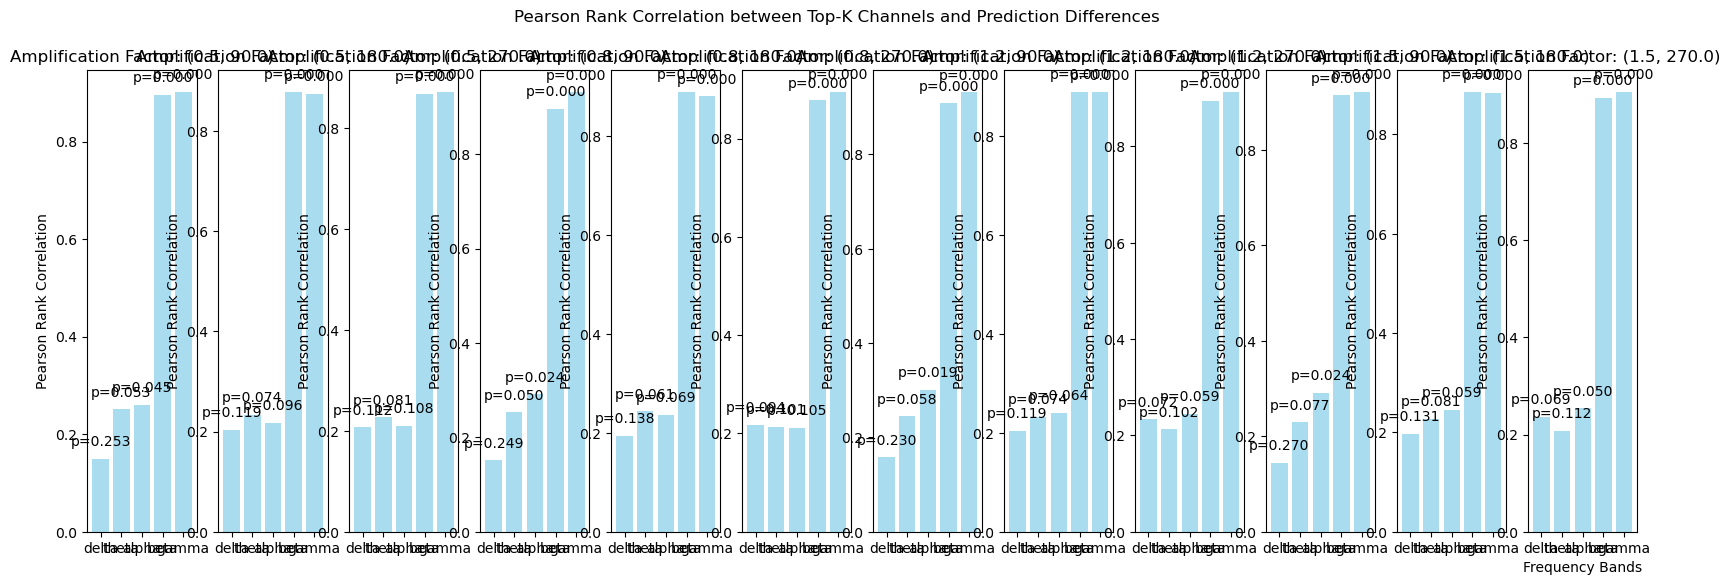

In [45]:
calculate_and_plot_rank_correlation(topk2_abs, all_subjects_median_diff[2], perturbation_pairs, freq_bands)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

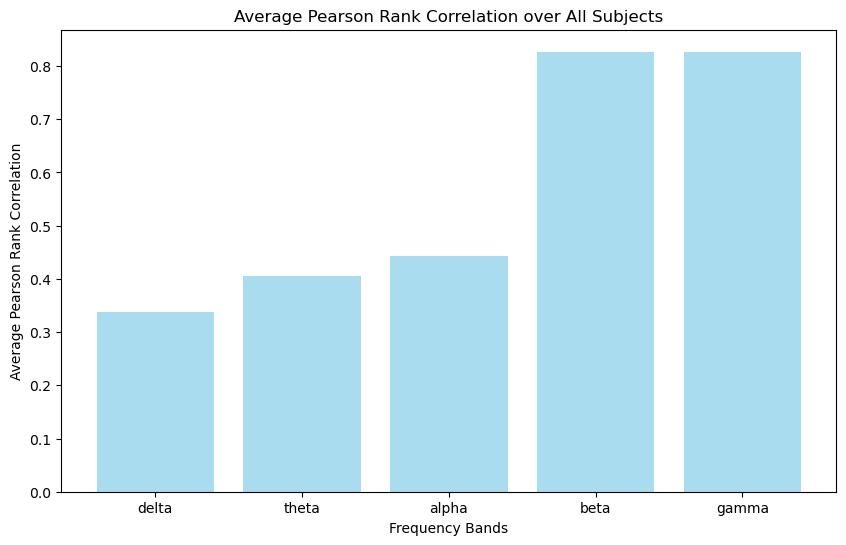

In [47]:

def calculate_average_rank_correlation(cfg, freq_bands, amplification_factors,rep=1, amp_factor=1.5, phase_shift=90):
    """
    Calculate the average rank correlation over all subjects.

    Parameters:
    cfg (omegaconf.dictconfig.DictConfig): Configuration object.
    freq_bands (dict): Dictionary of frequency bands.
    amplification_factors (list): List of amplification factors.

    Returns:
    dict: Average rank correlation results for each frequency band.
    """
    cfg = load_config()


    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
    #all_subjects_median_diff[subject_index] = prediction_diff_median_unsorted


    all_correlations = {band: [] for band in freq_bands.keys()}

    for subject_index in cfg.dataset.test_subject_indices:
        original_predictions,ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=rep)
        distances = load_distances(subject_index, perturbation_pairs, freq_bands, rep=1)
        mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw(original_predictions, freq_bands, perturbation_pairs, ch_names, distances, subject_index=subject_index, rep=1)
        top_60 = load_subject_topk(subject_index=subject_index,rep=rep)
        
        # Calculate rank correlation for each frequency band
        for band_name in freq_bands.keys():
            prediction_diff_values = list(median_diff_per_channel[band_name][(amp_factor, phase_shift)].values())
            top_k_60_values = list(top_60.values())
            correlation, _ = pearsonr(top_k_60_values, prediction_diff_values)
            all_correlations[band_name].append(correlation)

    # Calculate average correlation for each frequency band
    average_correlations = {band: np.nanmean(correlations) for band, correlations in all_correlations.items()}
    return average_correlations

def plot_average_rank_correlation(average_correlations):
    """
    Plot the average rank correlation over all subjects.

    Parameters:
    average_correlations (dict): Average rank correlation results for each frequency band.
    """
    bands = list(average_correlations.keys())
    avg_correlations = list(average_correlations.values())

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(bands, avg_correlations, color='skyblue', alpha=0.7)
    ax.set_xlabel('Frequency Bands')
    ax.set_ylabel('Average Pearson Rank Correlation')
    ax.set_title('Average Pearson Rank Correlation over All Subjects')
    plt.savefig("Average_Rank_Correlation_All_Subjects_power.png")
    #plt.show()

# Calculate and plot average rank correlation
average_correlations = calculate_average_rank_correlation(cfg, freq_bands, amplification_factors, rep=1)
plot_average_rank_correlation(average_correlations)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

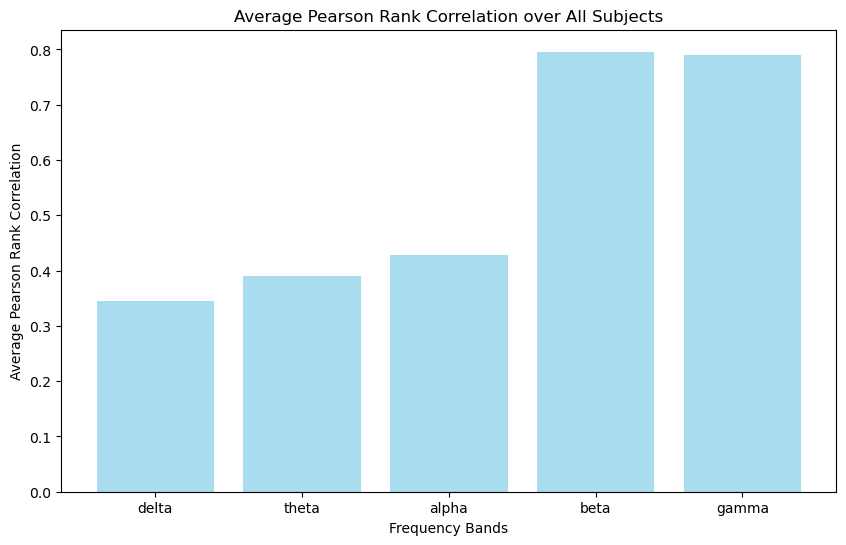

In [48]:
average_correlations = calculate_average_rank_correlation(cfg, freq_bands, amplification_factors, rep=1, amp_factor=0.5, phase_shift=180)
plot_average_rank_correlation(average_correlations)

# compare effect of joint vs individual perturbation

In [31]:
cfg = load_config()

all_subjects_median_diff_phase = {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index)
    distances = load_distances_phase(subject_index, phase_perturbations, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw_phase(original_predictions, freq_bands, phase_perturbations, ch_names, distances, subject_index=subject_index, rep=1)
    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, phase_perturbations)
    all_subjects_median_diff_phase[subject_index] = median_diff_per_channel

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [32]:
cfg = load_config()

all_subjects_median_diff_power= {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index)
    distances = load_distances_power(subject_index, amplification_factors, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw_power(original_predictions, freq_bands, amplification_factors, ch_names, distances, subject_index=subject_index, rep=1)
    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
    all_subjects_median_diff_power[subject_index] = median_diff_per_channel

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [41]:
np.mean(list(all_subjects_median_diff_phase[1]["gamma"][180].values()))

0.0008120521733706703

In [39]:
np.mean(list(all_subjects_median_diff_power[1]["gamma"][1.5].values()))

0.0008012447804444067

In [40]:
np.mean(list(all_subjects_median_diff_both[1]["gamma"][(1.5,180.0)].values()))

0.0008097168393740329

given that when adjusting for distanec the effect is the same, there seems to be a linear reltion between a power and a phase shift

if simultaneous power and phase shift is distance weighted, you get similar results as for a distance weighted power or phase shift

In [ ]:


def plot_frequency_band_distributions_average_corrected(all_subjects_avg_diffs_multi_band, freq_band_pairs_dict, all_subjects_avg_diffs, freq_bands, figsize=(15, 8), sharey=True, sharex=True, xlog=False):
        """
        Plot histograms showing the distribution of corrected average differences by frequency band pair.
        The correction subtracts individual band effects from the paired effect.
        """
        # Calculate corrected values - subtract individual band contributions
        corrected_diffs = {}
        
        for subject_id in all_subjects_avg_diffs_multi_band.keys():
            corrected_diffs[subject_id] = {}
            
            for band_pair in freq_band_pairs_dict.keys():
                band1, band2 = band_pair
                
                # Get pair value and individual band values
                pair_value = all_subjects_avg_diffs_multi_band[subject_id][band_pair]
                band1_value = all_subjects_avg_diffs[subject_id][band1]
                band2_value = all_subjects_avg_diffs[subject_id][band2]
                
                # Calculate corrected value by subtracting individual contributions
                corrected_diffs[subject_id][band_pair] = pair_value - band1_value - band2_value
        
        # Calculate number of subplots needed
        num_bands = len(freq_band_pairs_dict)
        # Calculate grid dimensions
        num_cols = int(np.ceil(np.sqrt(num_bands)))
        num_rows = int(np.ceil(num_bands / num_cols))
        
        # Create a subplot grid
        fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=figsize, sharey=sharey, sharex=sharex)
        fig.suptitle('Distribution of Corrected Interaction Effects', fontsize=20, y=1.02)
        
        # Make axes a 2D array even if there's only one row
        if num_rows == 1:
            axes = np.array([axes])
            
        # Flatten the axes for easier iteration
        axes_flat = axes.flatten()

        # Collect statistics
        band_means = {}
        band_medians = {}
        
        for band_pair in freq_band_pairs_dict.keys():
            band_data = [subject_values[band_pair] for subject_id, subject_values in corrected_diffs.items()]
            band_means[band_pair] = np.mean(band_data)
            band_medians[band_pair] = np.median(band_data)

        # Plot each frequency band pair
        for i, band_pair in enumerate(freq_band_pairs_dict.keys()):
            if i >= len(axes_flat):
                break  # Safety check
            
            band_data = [subject_values[band_pair] for subject_id, subject_values in corrected_diffs.items()]
            
            # Plot histogram with kernel density estimate
            sns.histplot(
                band_data, 
                kde=True, 
                ax=axes_flat[i], 
                alpha=0.7,
                edgecolor='white',
                linewidth=0.8,
            )
            
            if xlog:
                axes_flat[i].set_xscale('log')
            
            # Add mean line
            mean_value = band_means[band_pair]
            axes_flat[i].axvline(x=mean_value, color='black', linestyle='-', linewidth=1.5, 
                          label=f'Mean: {mean_value:.3e}')
      
            # Format title to show band pair
            band1, band2 = band_pair
            axes_flat[i].set_title(f'{band1}-{band2}', 
                            fontsize=14, fontweight='bold')
            
            # Add y-label only for the leftmost plots
            if i % num_cols == 0:
                axes_flat[i].set_ylabel('Count', fontsize=12)
                
            # Add x-label for bottom plots
            if i >= num_bands - num_cols:
                axes_flat[i].set_xlabel('Corrected Difference', fontsize=12)
            
            # Format ticks
            axes_flat[i].tick_params(axis='both', labelsize=10)
            
            # Clean up spines
            sns.despine(ax=axes_flat[i])

        # Hide unused subplots
        for j in range(i+1, len(axes_flat)):
            axes_flat[j].set_visible(False)

        plt.tight_layout()
        plt.subplots_adjust(top=0.92, wspace=0.2, hspace=0.3)
        
        return fig, axes, corrected_diffs

In [46]:
cfg = load_config()

all_subjects_median_diff_both = {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=1)
    distances = load_distances_both(subject_index, perturbation_pairs, freq_bands, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw_both(original_predictions, freq_bands, perturbation_pairs, ch_names, distances, subject_index=subject_index, rep=1, dw=False)
    all_subjects_median_diff_both[subject_index] = median_diff_per_channel
    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
    #all_subjects_median_diff[subject_index] = prediction_diff_median_unsorted

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [47]:
cfg = load_config()

all_subjects_median_diff_phase = {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index)
    distances = load_distances_phase(subject_index, phase_perturbations, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw_phase(original_predictions, freq_bands, phase_perturbations, ch_names, distances, subject_index=subject_index, rep=1, dw=False)
    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, phase_perturbations)
    all_subjects_median_diff_phase[subject_index] = median_diff_per_channel

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [48]:
cfg = load_config()

all_subjects_median_diff_power= {}
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index)
    distances = load_distances_power(subject_index, amplification_factors, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel_dw_power(original_predictions, freq_bands, amplification_factors, ch_names, distances, subject_index=subject_index, rep=1, dw=False)
    #prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
    all_subjects_median_diff_power[subject_index] = median_diff_per_channel

Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

In [49]:
all_subjects_median_diff_phase[1]["gamma"][180]

{'Fp1': 0.04907265305519104,
 'Fp2': 0.04608827829360962,
 'F3': 0.08002914488315582,
 'F4': 0.055777549743652344,
 'C3': 0.04399317502975464,
 'C4': 0.06532013416290283,
 'P3': 0.026335179805755615,
 'P4': 0.058109432458877563,
 'O1': 0.36543015390634537,
 'O2': 0.23497620224952698,
 'F7': 0.037087082862854004,
 'F8': 0.0518798828125,
 'T7': 0.04415455460548401,
 'T8': 0.07337073981761932,
 'P7': 0.09273108839988708,
 'P8': 0.04611863195896149,
 'Fz': 0.05551332235336304,
 'Cz': 0.0794215202331543,
 'Pz': 0.03757047653198242,
 'Iz': 0.020345687866210938,
 'FC1': 0.07424882054328918,
 'FC2': 0.18784093856811523,
 'CP1': 0.049321919679641724,
 'CP2': 0.036270350217819214,
 'FC5': 0.058043092489242554,
 'FC6': 0.035963237285614014,
 'CP5': 0.21247601509094238,
 'CP6': 0.055055126547813416,
 'F1': 0.12089230865240097,
 'F2': 0.0657515823841095,
 'C1': 0.02859443426132202,
 'C2': 0.0911821722984314,
 'P1': 0.08337152004241943,
 'P2': 0.09633608162403107,
 'AF3': 0.0962401032447815,
 'AF4':

In [51]:
all_subjects_median_diff_power[1]["gamma"][1.5]

{'Fp1': 0.012691468000411987,
 'Fp2': 0.01155206561088562,
 'F3': 0.026230022311210632,
 'F4': 0.01599729061126709,
 'C3': 0.010988950729370117,
 'C4': 0.016897499561309814,
 'P3': 0.006479203701019287,
 'P4': 0.014209508895874023,
 'O1': 0.08653444051742554,
 'O2': 0.06314492225646973,
 'F7': 0.009577959775924683,
 'F8': 0.012188613414764404,
 'T7': 0.011332392692565918,
 'T8': 0.018833905458450317,
 'P7': 0.024825870990753174,
 'P8': 0.011012688279151917,
 'Fz': 0.014678120613098145,
 'Cz': 0.02083563804626465,
 'Pz': 0.009353339672088623,
 'Iz': 0.004652723670005798,
 'FC1': 0.020272180438041687,
 'FC2': 0.04655294120311737,
 'CP1': 0.012530535459518433,
 'CP2': 0.008816808462142944,
 'FC5': 0.014499157667160034,
 'FC6': 0.009377241134643555,
 'CP5': 0.03987759351730347,
 'CP6': 0.01281234622001648,
 'F1': 0.026681363582611084,
 'F2': 0.015160143375396729,
 'C1': 0.0070849210023880005,
 'C2': 0.018781960010528564,
 'P1': 0.020397305488586426,
 'P2': 0.02307283878326416,
 'AF3': 0.02

In [50]:
all_subjects_median_diff_both[1]["gamma"][(1.5,180.0)]

{'Fp1': 0.06066805124282837,
 'Fp2': 0.05796431005001068,
 'F3': 0.09206786751747131,
 'F4': 0.06980673223733902,
 'C3': 0.052364498376846313,
 'C4': 0.08262482285499573,
 'P3': 0.03223416209220886,
 'P4': 0.07164713740348816,
 'O1': 0.3833569586277008,
 'O2': 0.3117624819278717,
 'F7': 0.045633792877197266,
 'F8': 0.06605774164199829,
 'T7': 0.05468098819255829,
 'T8': 0.08923517167568207,
 'P7': 0.11660903692245483,
 'P8': 0.05811688303947449,
 'Fz': 0.06812107563018799,
 'Cz': 0.09581676125526428,
 'Pz': 0.04762609302997589,
 'Iz': 0.026929914951324463,
 'FC1': 0.09792578220367432,
 'FC2': 0.24075919389724731,
 'CP1': 0.06433957815170288,
 'CP2': 0.04575732350349426,
 'FC5': 0.06971213221549988,
 'FC6': 0.04377129673957825,
 'CP5': 0.2728285603225231,
 'CP6': 0.07142773270606995,
 'F1': 0.15255749970674515,
 'F2': 0.08202135562896729,
 'C1': 0.03567767143249512,
 'C2': 0.11396008729934692,
 'P1': 0.10573440790176392,
 'P2': 0.1223919689655304,
 'AF3': 0.12097567319869995,
 'AF4': 0.

effects of phase shift and power amplification appear additive